In [1]:
# !pip install -e /files/shared/ap/jupyter-notebook/pkgs/objFuncs --break-system-packages
# !pip install -e /files/shared/ap/jupyter-notebook/pkgs/pyBO --break-system-packages

In [2]:
# !pip install -e /files/shared/ap/jupyter-notebook/pkgs/objFuncs
# !pip install -e /files/shared/ap/jupyter-notebook/pkgs/pyBO

In [3]:
# !pip install -e ../../objFuncs
# !pip install -e ../../pyBO

### This template is for
- objFuncs: v1.0.4  
- pyBO: v1.0.2

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
import objFuncs
from objFuncs import VM, objFuncGoals, construct_machineIO
from objFuncs.preset import get_preset, get_tolerance, get_limits
from pyBO import pyBO

objFuncs version: 1.0.4. updated on 2024-03-26
flame_utils is not importable. ignoreing this feature...
pyBO version: 1.0.2. updated on 2024-03-26


In [6]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time
import datetime
import concurrent
import pandas as pd

# user inputs
### check and adjust decision (control knobs) and objectives later

In [7]:
is_close_to_opt = False     # True for local optimization. 
timespan_for_average = 2.0  # sec  
additional_wait_after_powersupply_ramp  = 2.0 # sec

In [8]:
if is_close_to_opt:
    n_init_budget       = 4   # recommended: number of decision parameters 
    n_global_opt_budget = 0
    n_local_opt_budget  = 8
    n_finetune_budget   = 1   # recommended: less than number of decision parameters 
else:
    n_init_budget       = 5         
    n_global_opt_budget = 5
    n_local_opt_budget  = 8
    n_finetune_budget   = 1   # recommended: less than number of decision parameters 

budget = n_init_budget +n_global_opt_budget +n_local_opt_budget +n_finetune_budget
print(f"budget: {budget}")

budget: 19


# check machineIO, source and beam  

In [9]:
objFuncs._global_machineIO._test = True
objFuncs._global_machineIO._fetch_data_time_span = timespan_for_average
objFuncs._global_machineIO._ensure_set_timewait_after_ramp = additional_wait_after_powersupply_ramp

# preprare decision ( control knob)

In [10]:
# preset = get_preset('[MEBT]FC1102',offline=True)
# preset

In [11]:
decision_CSETs = [
                 'FE_MEBT:RFC_D1066:PHA_CSET', 'FE_MEBT:RFC_D1107:PHA_CSET',
                  ]
decision_min   = np.array([ 12, 26])
decision_max   = np.array([ 15, 29])
decision_tols  = [0.2]*len(decision_CSETs)

pd.DataFrame(np.array([decision_min,decision_max,decision_tols]).T,
             index=decision_CSETs, 
             columns=['decision min','decision max','tol'])

,decision min,decision max,tol
FE_MEBT:RFC_D1066:PHA_CSET,12.0,15.0,0.2
FE_MEBT:RFC_D1107:PHA_CSET,26.0,29.0,0.2


# preprare objective function

In [12]:
objective_goal= {
    'FE_MEBT:BPM_D1056:XPOS_RD' : 0,
    'FE_MEBT:BPM_D1056:YPOS_RD' : 0,
}

In [13]:
objective_norm= {
    'FE_MEBT:BPM_D1056:XPOS_RD' : 1,
    'FE_MEBT:BPM_D1056:YPOS_RD' : 1,
}

In [14]:
# set weight to zero if you don't want to include the corresponding objective

objective_weight= {
    'FE_MEBT:BPM_D1056:XPOS_RD' : 1,
    'FE_MEBT:BPM_D1056:YPOS_RD' : 1,
}

# construct VM

In [15]:
machineIO = construct_machineIO()
machineIO._test = True

In [16]:
objective_RDs_mean = []
for k,v in objective_goal.items():
    if isinstance(v, dict):
        v = list(v.values())[0]
    objective_RDs_mean.append(v - 2*objective_norm[k])

In [17]:
vm = VM(
    x0 = 0.5*(decision_min+decision_max),
    decision_CSETs = decision_CSETs,
    decision_min   = np.array(decision_min),
    decision_max   = np.array(decision_max),
    objective_RDs  = list(objective_goal.keys()),
    objective_RDs_mean = np.array(objective_RDs_mean) - 1,
    objective_RDs_std  = [val for val in objective_norm.values()],
    real_time_delay = 0,
)

In [18]:
machineIO._ensure_set = vm.ensure_set
machineIO._fetch_data = vm.fetch_data
machineIO._caget      = vm.caget
machineIO._caput      = vm.caput

In [19]:
obj = objFuncGoals(
    decision_CSETs=decision_CSETs,
    decision_min = decision_min,
    decision_max = decision_max,
    decision_tols = decision_tols,
    objective_goal = objective_goal,
    objective_weight = objective_weight,
    objective_norm = objective_norm,
    apply_bilog = False,
    machineIO=machineIO,
);

======== class info ========
init_time: 2024-08-16 13:56:35.950476
class_hierarchy: [
    objFuncGoals, objFuncBase]
machineIO: not picklable
decision_CSETs: [
    FE_MEBT:RFC_D1066:PHA_CSET, FE_MEBT:RFC_D1107:PHA_CSET]
decision_min: [12. 26.]
decision_max: [15. 29.]
decision_bounds: [[12 15]
 [26 29]]
decision_RDs: [
    FE_MEBT:RFC_D1066:PHA_RD, FE_MEBT:RFC_D1107:PHA_RD]
decision_tols: [0.2 0.2]
decision_couplings: None
history_buffer_size: None
logging_frequency: inf
logging_tag: 
logging_fname: None
x0: [13.5 27.5]
plot_time_val: <class 'objFuncs.util.plot_time_val'>
plot_obj_history: <class 'objFuncs.util.plot_obj_history'>
objective_weight:
    FE_MEBT:BPM_D1056:XPOS_RD: 0.5
    FE_MEBT:BPM_D1056:YPOS_RD: 0.5
objective_goal:
    FE_MEBT:BPM_D1056:XPOS_RD: 0.0
    FE_MEBT:BPM_D1056:YPOS_RD: 0.0
objective_norm:
    FE_MEBT:BPM_D1056:XPOS_RD: 1
    FE_MEBT:BPM_D1056:YPOS_RD: 1
objective_RDs: [
    FE_MEBT:BPM_D1056:XPOS_RD, FE_MEBT:BPM_D1056:YPOS_RD]
objective_p_order: 2
apply_bilog

In [20]:
machineIO = construct_machineIO()
machineIO._test = True
machineIO._fetch_data_time_span = 0.0
machineIO._ensure_set_timewait_after_ramp = 0.0
machineIO._ensure_set = vm.ensure_set
machineIO._fetch_data = vm.fetch_data
machineIO._caget      = vm.caget
machineIO._caput      = vm.caput

obj4plot = objFuncGoals(
    decision_CSETs=decision_CSETs,
    decision_min = decision_min,
    decision_max = decision_max,
    decision_tols = decision_tols,
    objective_goal = objective_goal,
    objective_weight = objective_weight,
    objective_norm = objective_norm,
    apply_bilog = False,
    machineIO=machineIO,
);

======== class info ========
init_time: 2024-08-16 13:56:35.969542
class_hierarchy: [
    objFuncGoals, objFuncBase]
machineIO: not picklable
decision_CSETs: [
    FE_MEBT:RFC_D1066:PHA_CSET, FE_MEBT:RFC_D1107:PHA_CSET]
decision_min: [12. 26.]
decision_max: [15. 29.]
decision_bounds: [[12 15]
 [26 29]]
decision_RDs: [
    FE_MEBT:RFC_D1066:PHA_RD, FE_MEBT:RFC_D1107:PHA_RD]
decision_tols: [0.2 0.2]
decision_couplings: None
history_buffer_size: None
logging_frequency: inf
logging_tag: 
logging_fname: None
x0: [13.5 27.5]
plot_time_val: <class 'objFuncs.util.plot_time_val'>
plot_obj_history: <class 'objFuncs.util.plot_obj_history'>
objective_weight:
    FE_MEBT:BPM_D1056:XPOS_RD: 0.5
    FE_MEBT:BPM_D1056:YPOS_RD: 0.5
objective_goal:
    FE_MEBT:BPM_D1056:XPOS_RD: 0.0
    FE_MEBT:BPM_D1056:YPOS_RD: 0.0
objective_norm:
    FE_MEBT:BPM_D1056:XPOS_RD: 1
    FE_MEBT:BPM_D1056:YPOS_RD: 1
objective_RDs: [
    FE_MEBT:BPM_D1056:XPOS_RD, FE_MEBT:BPM_D1056:YPOS_RD]
objective_p_order: 2
apply_bilog

In [21]:
def plot_obj(train_x,best_x,bounds,local_bounds=None,grid_ponits_each_dim=16,obj=obj4plot,fig=None,ax=None):
    if fig is None:
        fig,ax = plt.subplots(figsize=(4,3),dpi=96)
    x1 = np.linspace(bounds[0,0], bounds[0,1], grid_ponits_each_dim)
    x2 = np.linspace(bounds[1,0], bounds[1,1], grid_ponits_each_dim)
    # Create a meshgrid
    x1, x2 = np.meshgrid(x1, x2)
    # Combine x and y coordinates into a (num_points_x * num_points_y, 2) array
    grid_x = np.vstack([x1.ravel(), x2.ravel()]).T
    grid_y = np.zeros(len(grid_x))
    for i,x in enumerate(grid_x):
        grid_y[i] = obj(x)
    cs = ax.tricontourf(grid_x[:,0], grid_x[:,1], grid_y, levels=64, cmap="viridis");
    fig.colorbar(cs,ax=ax,shrink=0.95)
    ax.scatter(train_x[:,0],train_x[:,1],color='blue',label='train data')
    ax.scatter(best_x[0],best_x[1],color='red',label='optimum solution')

    if local_bounds is not None:
        bounds = local_bounds
    
    rect = patches.Rectangle(
       (bounds[0, 0],  bounds[1, 0]),  # (x,y) bottom-left corner
        bounds[0, 1] - bounds[0, 0],  # width
        bounds[1, 1] - bounds[1, 0],  # height
        linewidth=2,
        edgecolor='gray',
        facecolor='none',
        linestyle='--'
    )
    ax.add_patch(rect)
    ax.plot([], [], color='gray', linestyle='--', linewidth=2, label='bounds')
    ax.legend()

    ax.set_xlabel(obj.decision_CSETs[0])
    ax.set_ylabel(obj.decision_CSETs[1])

    fig.tight_layout()

In [22]:
def plot_ctrBO(ctrBO,local_bounds=None,grid_ponits_each_dim=64,obj=obj4plot,fig=None,ax=None):
    bounds = ctrBO.bo.bounds
    if fig is None:
        fig,ax = plt.subplots(figsize=(4,3),dpi=96)
    x1 = np.linspace(bounds[0,0], bounds[0,1], grid_ponits_each_dim)
    x2 = np.linspace(bounds[1,0], bounds[1,1], grid_ponits_each_dim)
    # Create a meshgrid
    x1, x2 = np.meshgrid(x1, x2)
    # Combine x and y coordinates into a (num_points_x * num_points_y, 2) array
    grid_x = np.vstack([x1.ravel(), x2.ravel()]).T
    grid_y = ctrBO.bo.model(grid_x,return_var=False)
    train_x = ctrBO.bo.x
    best_x,_ = ctrBO.bo.best_sofar()
    cs = ax.tricontourf(grid_x[:,0], grid_x[:,1], grid_y, levels=64, cmap="viridis");
    fig.colorbar(cs,ax=ax,shrink=0.95)
    ax.scatter(train_x[:,0],train_x[:,1],color='blue',label='train data')
    ax.scatter(best_x[0],best_x[1],color='red',label='optimum solution')


    if local_bounds is not None:
        bounds = local_bounds
        
    rect = patches.Rectangle(
       (bounds[0, 0],  bounds[1, 0]),  # (x,y) bottom-left corner
        bounds[0, 1] - bounds[0, 0],  # width
        bounds[1, 1] - bounds[1, 0],  # height
        linewidth=2,
        edgecolor='gray',
        facecolor='none',
        linestyle='--'
    )
    ax.add_patch(rect)
    ax.plot([], [], color='gray', linestyle='--', linewidth=2, label='bounds')
    ax.legend()

    ax.set_xlabel(obj.decision_CSETs[0])
    ax.set_ylabel(obj.decision_CSETs[1])

    fig.tight_layout()

# run Optim

In [23]:
ctrBO = pyBO.bo_controller(obj,local_optimization = is_close_to_opt)

init will random sample within the following bounds:


,min,max
FE_MEBT:RFC_D1066:PHA_CSET,12,15
FE_MEBT:RFC_D1107:PHA_CSET,26,29


### init

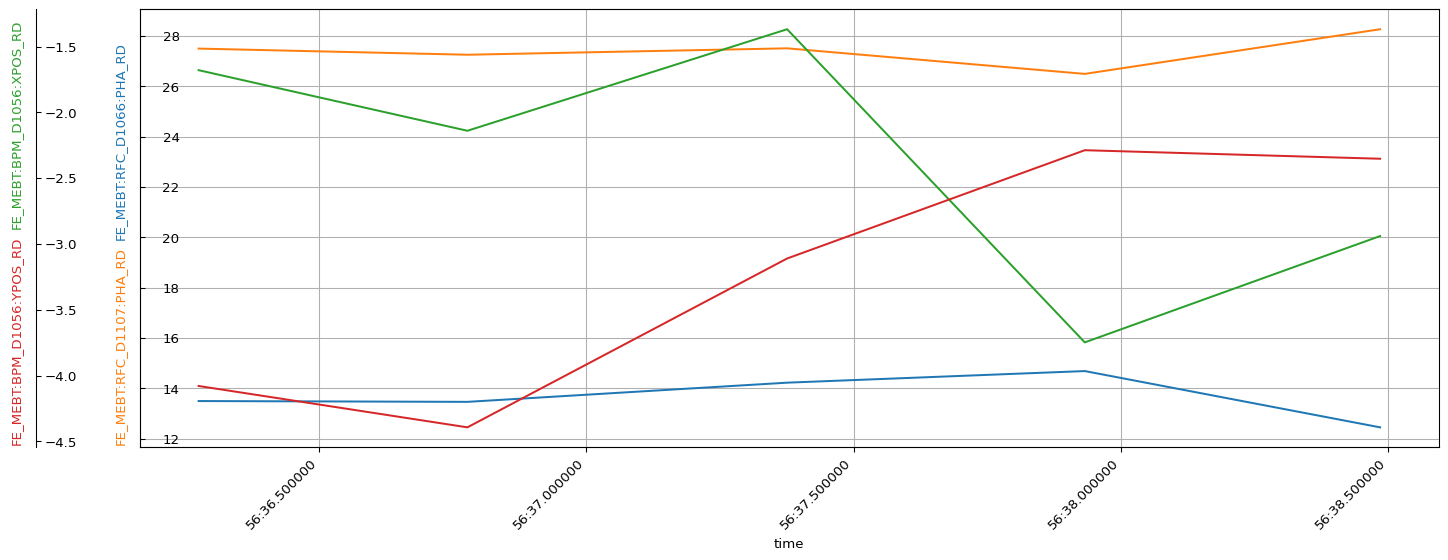

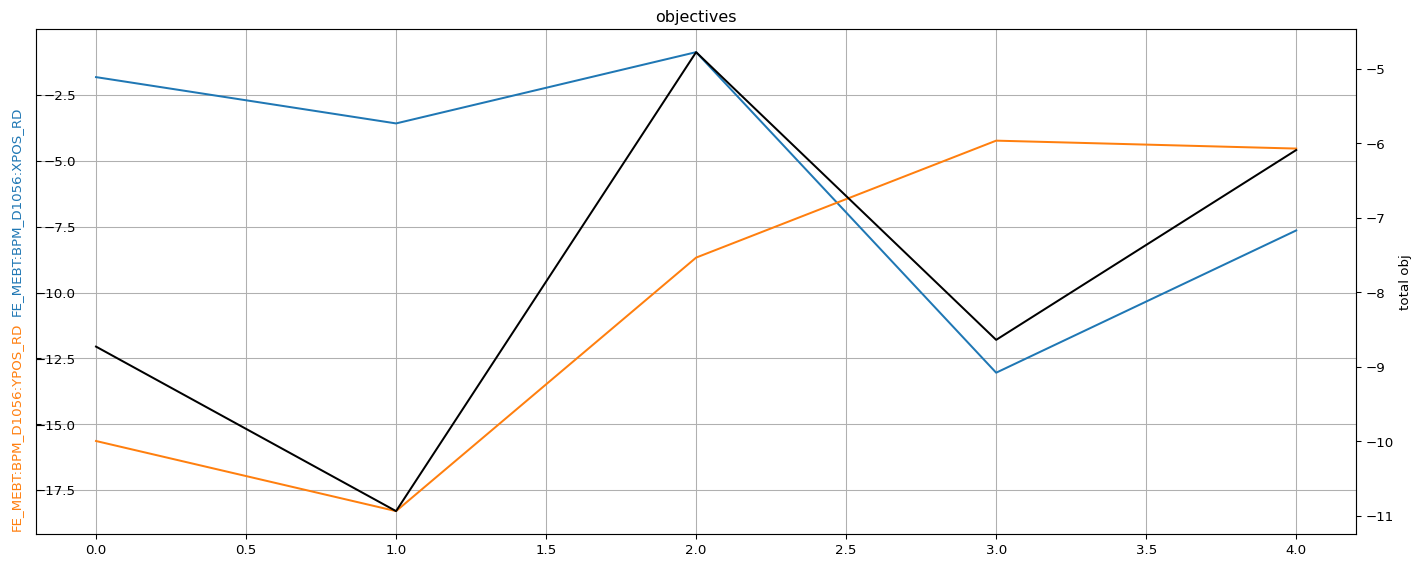

In [24]:
# optimize
ctrBO.init(n_init_budget)  
for f in ctrBO.plot_callbacks:
    f.close()

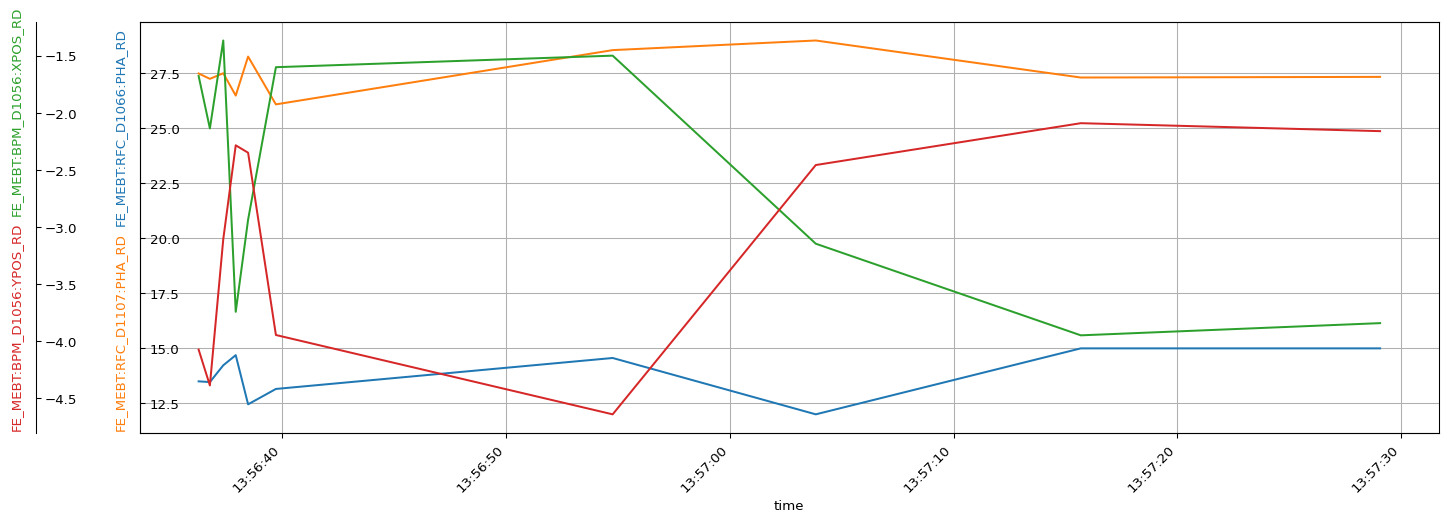

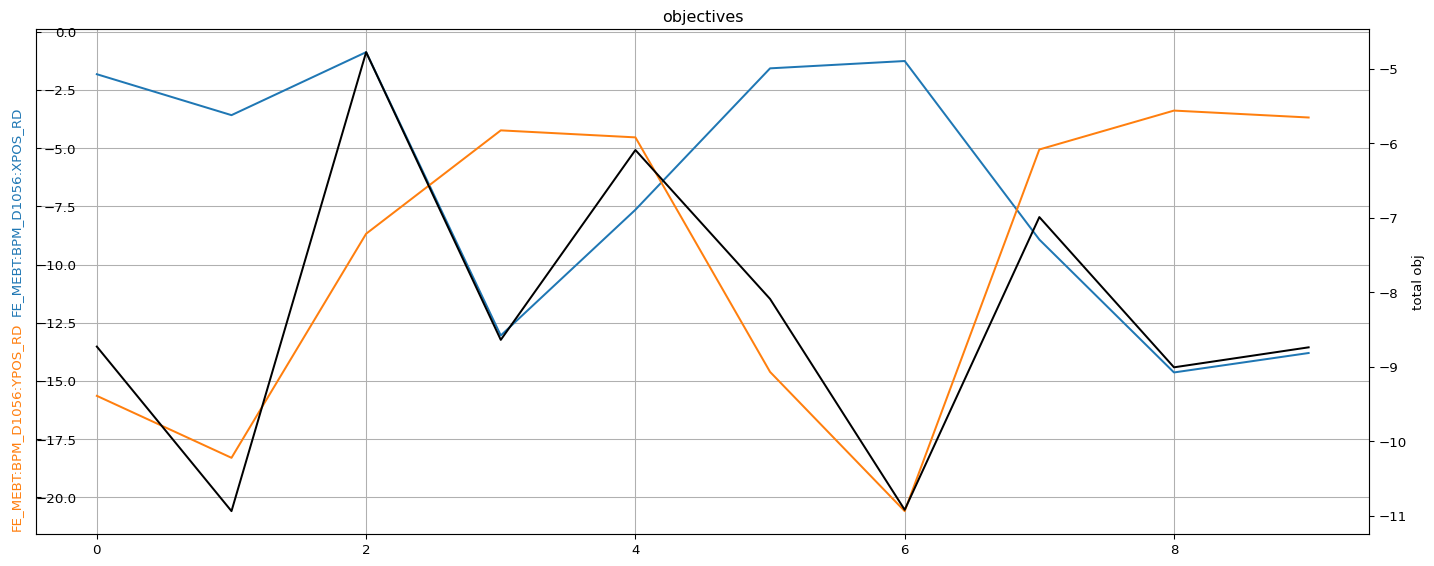

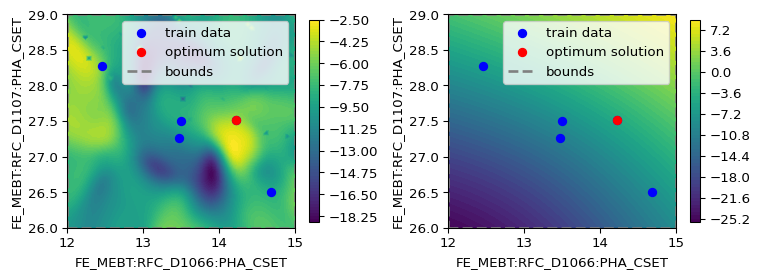

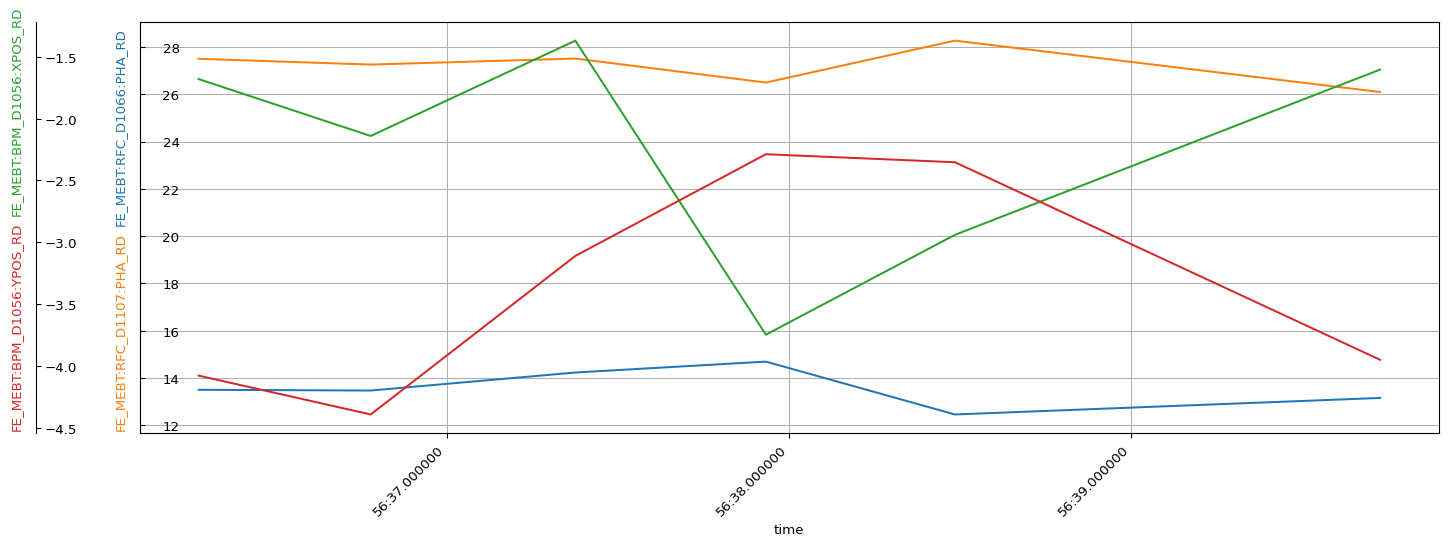

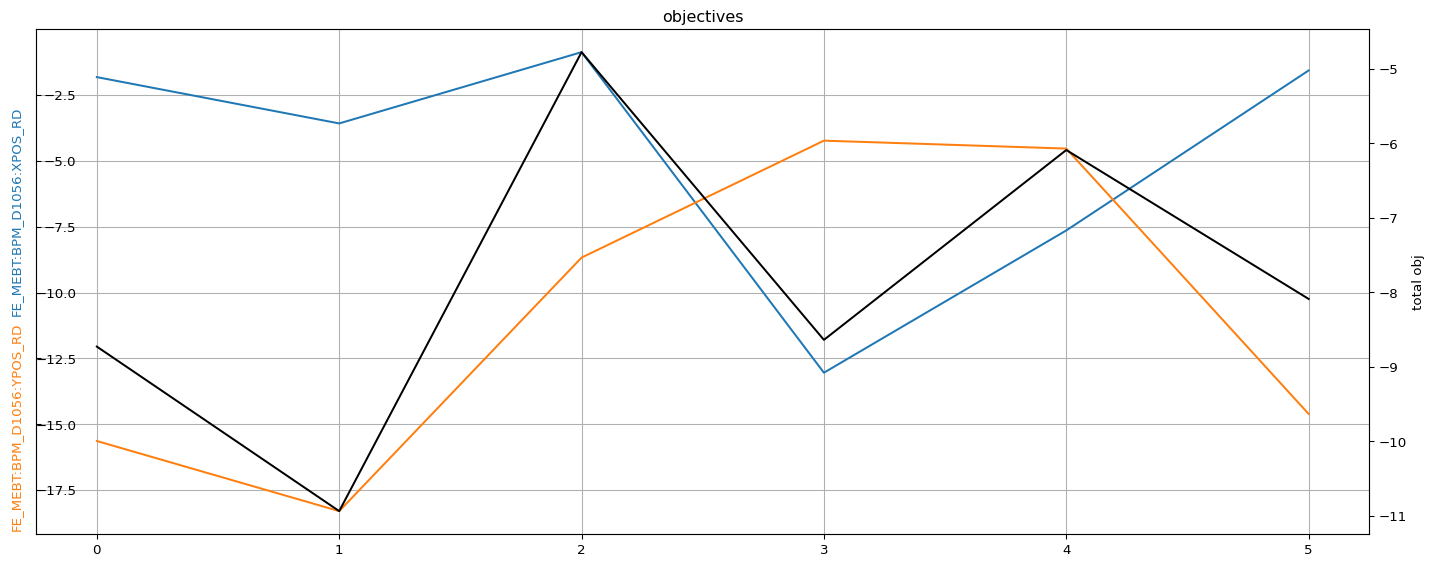

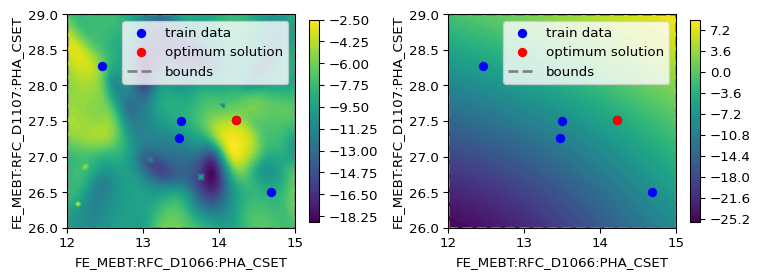

In [25]:
count = [0]
def _plot():
    fig,ax = plt.subplots(1,2,figsize=(8,3),dpi=96)
    bounds = ctrBO.bounds
    best_x,_ = ctrBO.bo.best_sofar()
    train_x = ctrBO.bo.x
    if hasattr(ctrBO,'local_bounds'):
        local_bounds = ctrBO.local_bounds
    else:
        local_bounds = None
    plot_obj(train_x,best_x,bounds,local_bounds=local_bounds,fig=fig,ax=ax[0],grid_ponits_each_dim=64)
    plot_ctrBO(ctrBO,fig=fig,local_bounds=local_bounds,ax=ax[1])
    fig.savefig(f'Global_vs_Local_{count[0]:03d}.png', dpi=96)
    count[0] += 1

ctrBO.plot_callbacks.append(_plot)
_plot()

### global opt

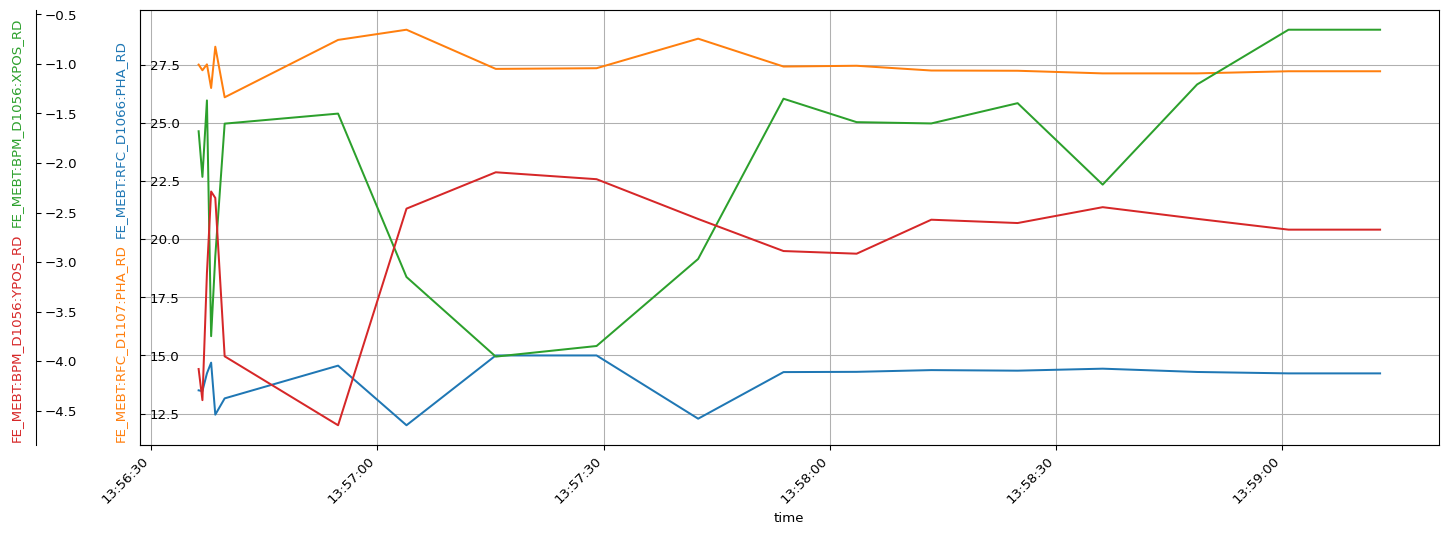

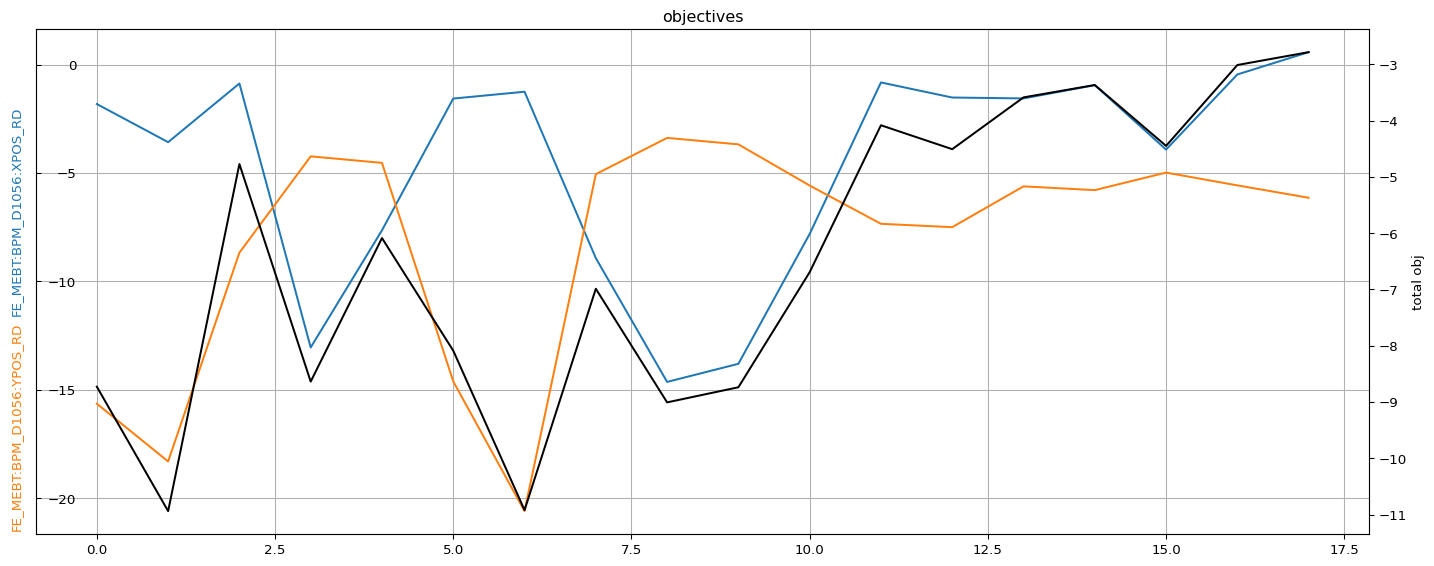

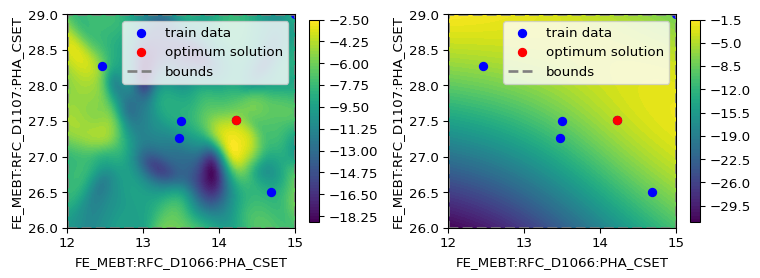

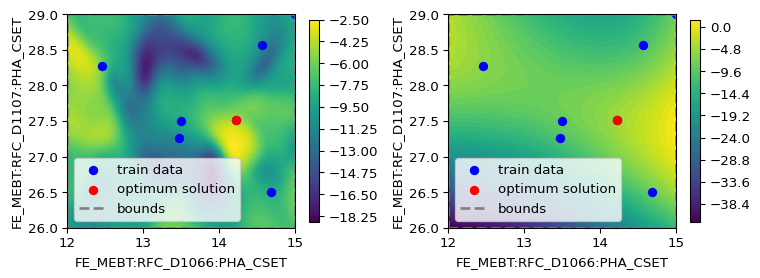

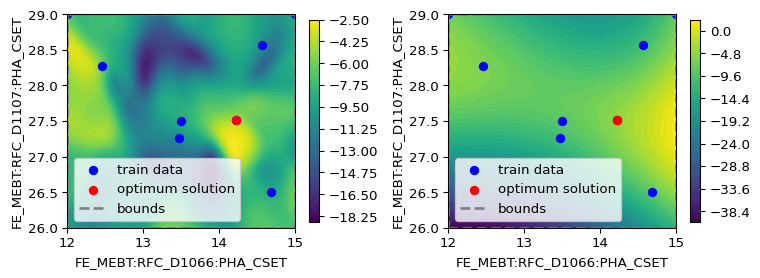

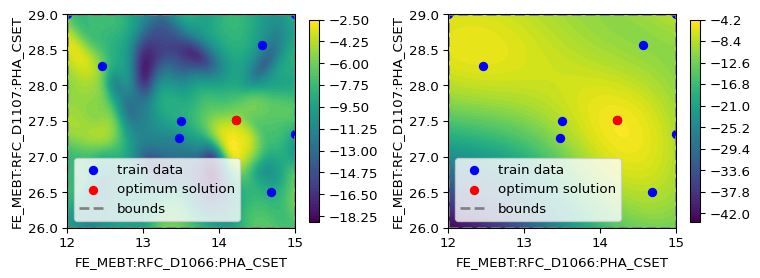

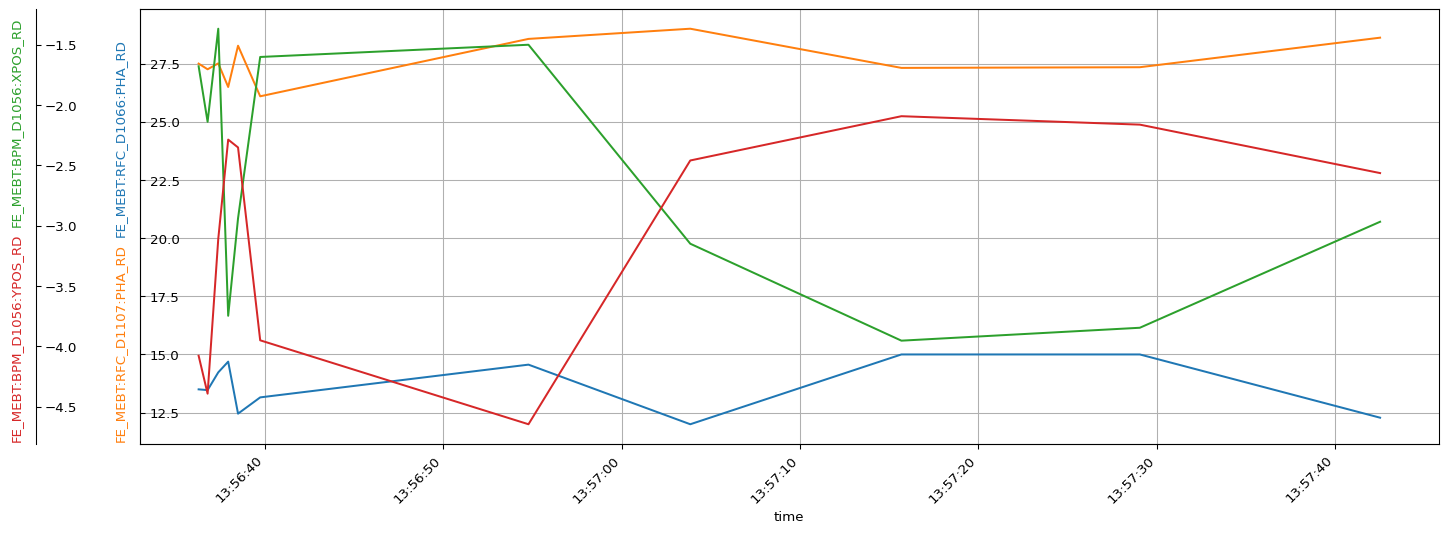

In [26]:
# optimize
ctrBO.optimize_global(n_global_opt_budget, beta_scheduler=None)
for f in ctrBO.plot_callbacks:
    try:
        f.close()
    except:
        pass

### local optim

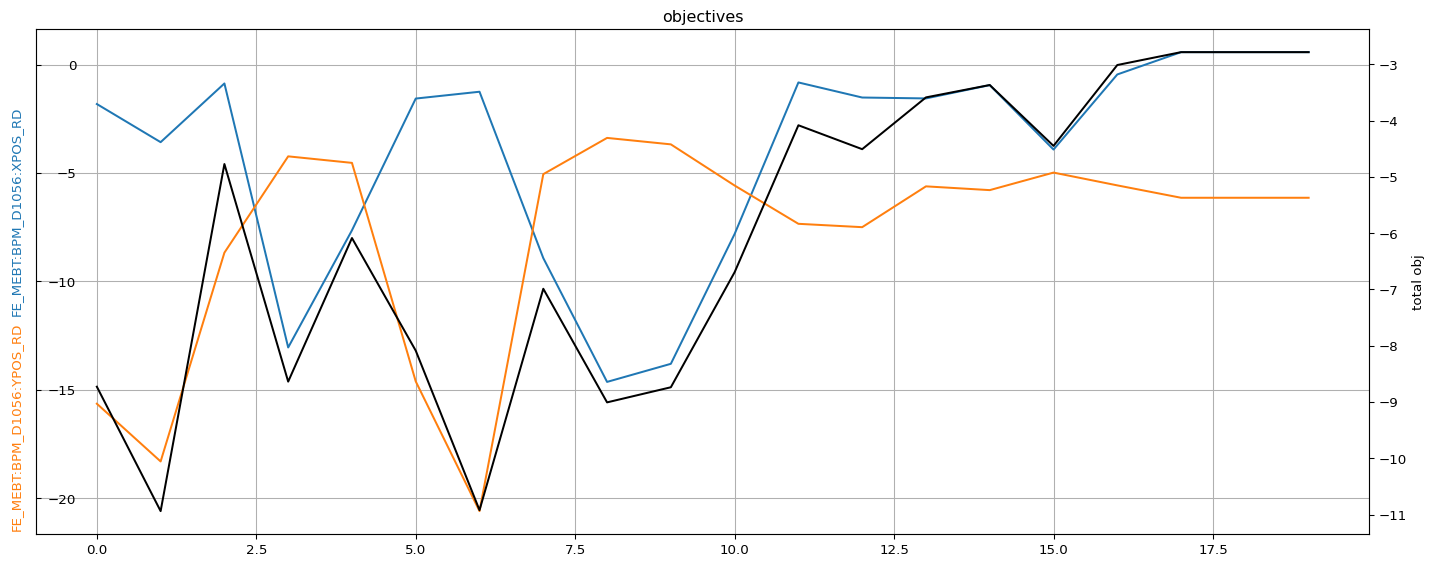

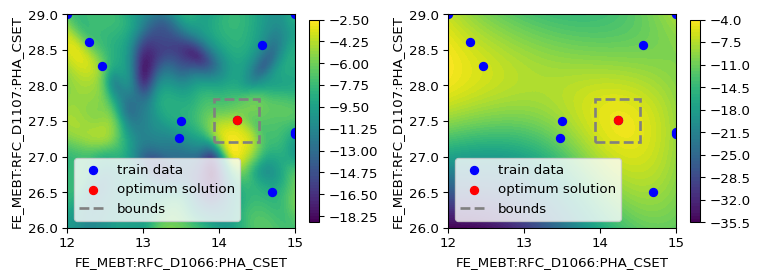

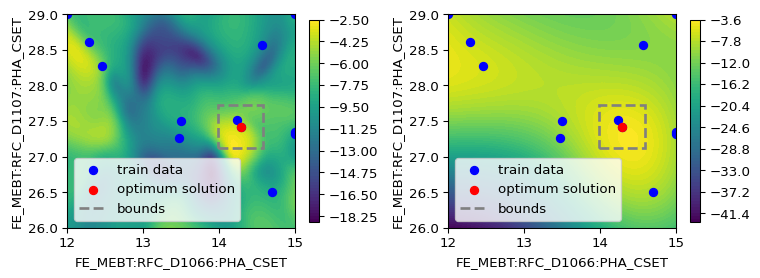

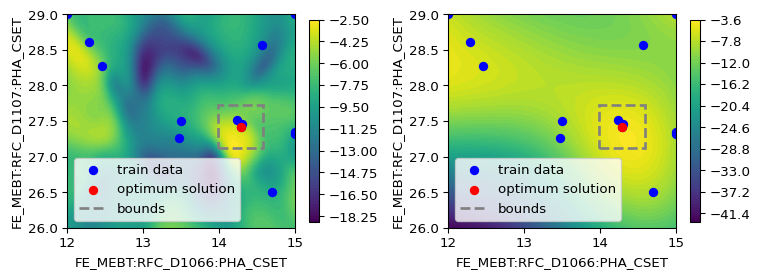

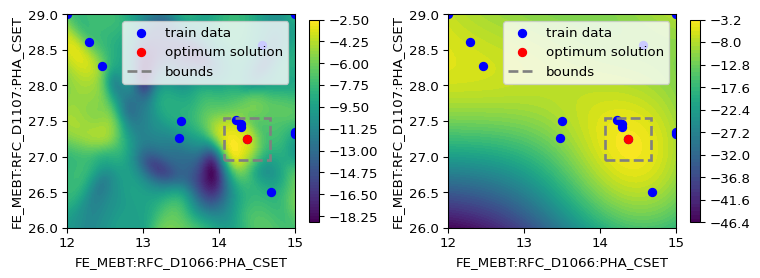

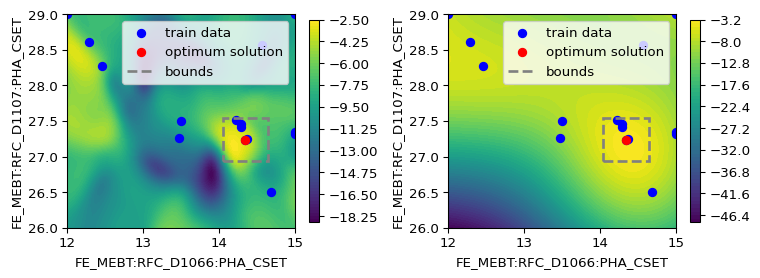

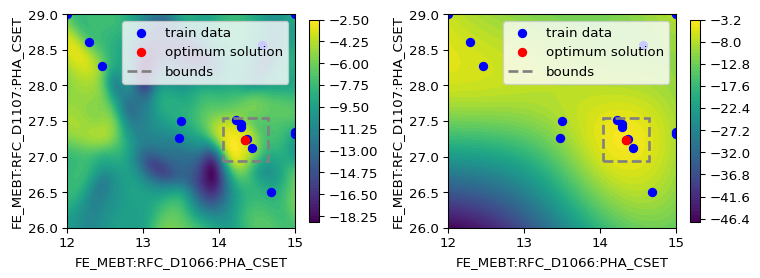

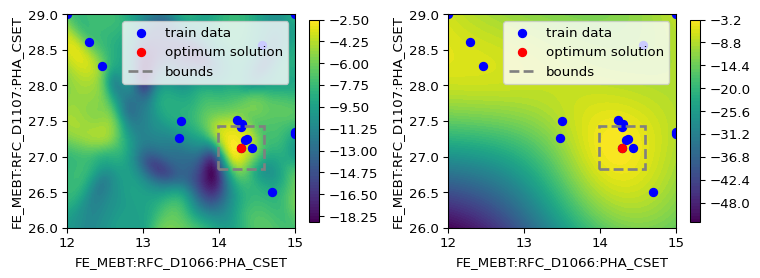

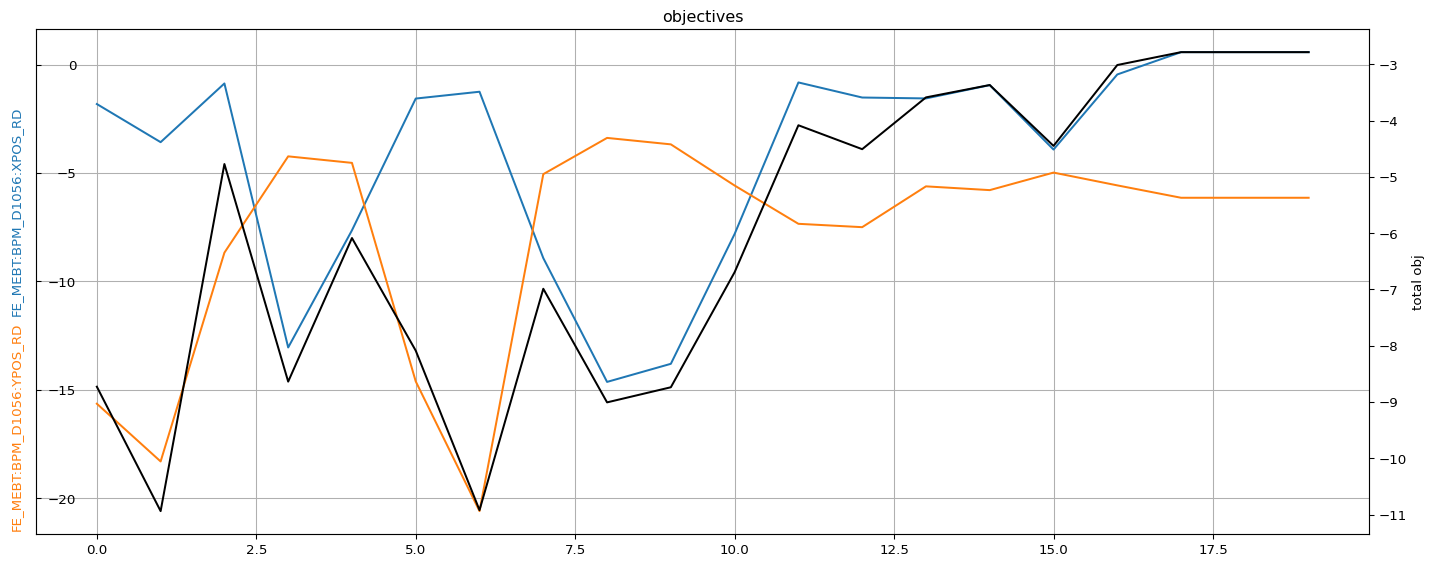

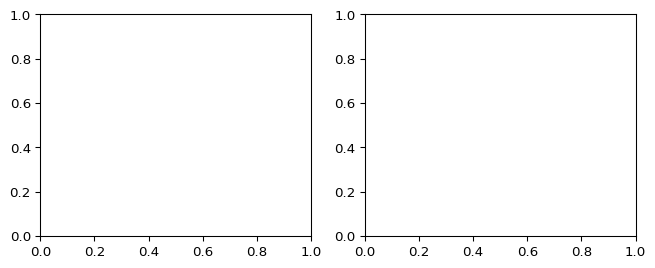

In [27]:
ctrBO.optimize_local (n_local_opt_budget , beta_scheduler=None)
x_best,y_best_old = ctrBO.bo.best_sofar()
obj(x_best)
for f in ctrBO.plot_callbacks:
    try:
        f.close()
    except:
        pass

<AxesSubplot: xlabel='evaluation budget', ylabel='best objective'>

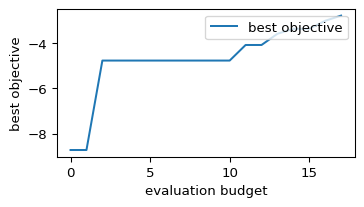

In [28]:
fig,ax = plt.subplots(figsize=(4,2),dpi=96)
ctrBO.bo.plot_obj_history(ax=ax, plot_best_only=True)